# Building Agents

## Getting Started

In [1]:
from IPython.display import Image, display
from typing import TypedDict, Annotated, Literal, List
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import add_messages, StateGraph, START, END
from langgraph.types import Command, interrupt
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition
import sqlite3 #in built with Python
import os
import uuid

In [2]:
load_dotenv(override=True)

True

## Initializing

### LLM

In [3]:
#1 Common API
llm = ChatOpenAI(
    model="openai-main/gpt-4",
    api_key=os.environ["TFY_API_KEY"],
    base_url="https://platform-admin.live-demo.truefoundry.cloud/api/llm",
    model_kwargs={
      "stream": False,
      "extra_headers":{
        "X-TFY-METADATA": '{}',
        "X-TFY-LOGGING-CONFIG": '{"enabled": true}',
      },
    },
)

### Tools

In [4]:
search_tool = TavilySearch(max_results=2)
tools = [search_tool]

In [5]:
llm_with_tools = llm.bind_tools(tools=tools)

## Adding Memory

**We are referring to short-term memory enabled by thread-level persistence here below, and not long-term memory which is across user or applications.**

### In-Memory

In [6]:
from langgraph.checkpoint.memory import InMemorySaver

In [7]:
memory = InMemorySaver()

In [8]:
tool_node = ToolNode(tools=tools)

In [9]:
class SimpleChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [10]:
def tool_enabled_chatbot(state: SimpleChatState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])], 
    }

In [11]:
#From scratch - else use tools_condition
graph = StateGraph(SimpleChatState)

graph.add_node("chatbot", tool_enabled_chatbot)
graph.add_node("tools", tool_node)
graph.set_entry_point("chatbot")

graph.add_conditional_edges("chatbot", 
                            tools_condition)

graph.add_edge("tools", "chatbot")

app = graph.compile(checkpointer=memory)

config = {"configurable": {
    "thread_id": 1
}}

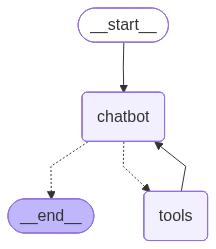

In [12]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
while True: 
    user_input = input("User: ")
    if(user_input in ["exit", "end"]):
        break
    else: 
        result = app.invoke({
            "messages": [HumanMessage(content=user_input)]
        }, config=config)

        print("AI: " + result["messages"][-1].content)

**With short-term memory, long conversations can lead to context length being exceeded. Common counteractions include trimming, deleting, summarizing messages and managing checkpoints.**

### External DB

**In production, we should use a checkpointer backed by a database.**

In [15]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3 #in built with Python

In [16]:
#Create a connection string
!mkdir checkpoints
sqlite_conn = sqlite3.connect("checkpoints/checkpoint.sqlite", check_same_thread=False)

# Note: check_same_thread=False is OK as the implementation uses a lock to ensure thread safety.

In [17]:
#Replace memory saver with SqliteSaver - everything else is same
memory = SqliteSaver(sqlite_conn)

**After every single node execution, this checkpointer will append new checkpoints and save the state.**

In [21]:
tool_node = ToolNode(tools=tools)

In [22]:
class SimpleChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [23]:
def tool_enabled_chatbot(state: SimpleChatState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])], 
    }

In [24]:
#From scratch - else use tools_condition
graph = StateGraph(SimpleChatState)

graph.add_node("chatbot", tool_enabled_chatbot)
graph.add_node("tools", tool_node)
graph.set_entry_point("chatbot")

graph.add_conditional_edges("chatbot", 
                            tools_condition)

graph.add_edge("tools", "chatbot")

app = graph.compile(checkpointer=memory)

config = {"configurable": {
    "thread_id": 1
}}

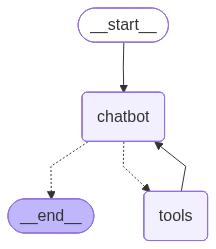

In [25]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [5]:
#Running again, it is able to recall - but after deleting SQLite, it'll not be able to recall
while True: 
    user_input = input("User: ")
    if(user_input in ["exit", "end"]):
        break
    else: 
        result = app.invoke({
            "messages": [HumanMessage(content=user_input)]
        }, config=config)

        print("AI: " + result["messages"][-1].content)

**When you delete the SQLite, it causes the memory to not work - "DELETE FROM checkpoints".**

# Human in the Loop

**Human-in-the-loop** workflow integrates human inputs into automated processes, and is especially useful as LLMs can generate inaccurate content or require more information occasionally:

- **Reviewing tool calls**: Reviewing, editing or approving tools calls requested by the LLM before execution 
- **Validating LLM outputs**: Reviewing, editing or approving content generated by LLM
- **Providing context**: For clarification or more details or to support multi-turn conversations

There are 4 key design patterns:

- **Approve or reject**: Depending on the human's approval or rejection, the graph can proceed with the action or take an alternative path.

<img src="images/approve-or-reject.png" width="30%" height = "30%" alt="Approve or reject">


- **Review and edit state**: A human can review and edit the state of the graph. This is useful for correcting mistakes or updating the state with additional information.

<img src="images/edit-graph-state-simple.png" width="40%" height = "40%" alt="Review and edit state">


- **Review tool calls**: A human can review and edit the output from the LLM before proceeding. This is particularly critical in applications where the tool calls requested by the LLM may be sensitive or require human oversight.

<img src="images/tool-call-review.png" width="40%" height = "40%" alt="Review tool calls">


- **Validating human input**: To validate the input provided by the human within the graph itself (rather than on the client side).

Let's take an example:

<img src="images/human-in-the-loop-example.png" width="20%" height = "20%" alt="Example">

## Basic Working Version

In [26]:
class State(TypedDict): 
    messages: Annotated[list, add_messages]

In [27]:
#1 Common API
llm = ChatOpenAI(
    model="openai-main/gpt-4",
    api_key=os.environ["TFY_API_KEY"],
    base_url="https://platform-admin.live-demo.truefoundry.cloud/api/llm",
    model_kwargs={
      "stream": False,
      "extra_headers":{
        "X-TFY-METADATA": '{}',
        "X-TFY-LOGGING-CONFIG": '{"enabled": true}',
      },
    },
)

In [28]:
GENERATE_POST = "generate_post"
GET_REVIEW_DECISION = "get_review_decision"
POST = "post"
COLLECT_FEEDBACK = "collect_feedback"

In [29]:
#Add node
def generate_post(state: State): 
    return {
        "messages": [llm.invoke(state["messages"])]
    }

In [30]:
#Add node
def post(state: State):  
    final_post = state["messages"][-1].content  
    print("\nFinal Tweet:\n")
    print(final_post)
    print("\nTweet has been approved and is now live on Twitter!")

In [31]:
#Add node
def collect_feedback(state: State):  
    feedback = input("How can I improve this tweet?")
    return {
        "messages": [HumanMessage(content=feedback)]
    }

In [32]:
#Add conditional edge
def get_review_decision(state: State) -> Literal["post", "collect_feedback"]:  
    post_content = state["messages"][-1].content 
    
    print("\nCurrent Tweet:\n")
    print(post_content)
    print("\n")

    decision = input("Tweet? (yes/no): ")

    if decision.lower() == "yes":
        return "post"
    else:
        return "collect_feedback"

In [33]:
graph = StateGraph(State)

graph.add_node(GENERATE_POST, generate_post)
graph.add_node(COLLECT_FEEDBACK, collect_feedback)
graph.add_node(POST, post)

graph.set_entry_point(GENERATE_POST)

graph.add_conditional_edges(GENERATE_POST, 
                            get_review_decision)
graph.add_edge(COLLECT_FEEDBACK, GENERATE_POST)
graph.add_edge(POST, END)

app = graph.compile()

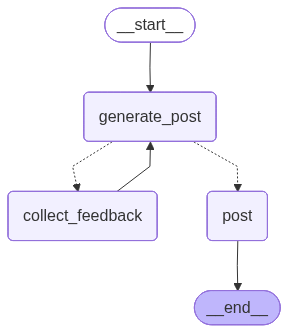

In [34]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [2]:
response = app.invoke({
    "messages": [HumanMessage(content="Write me a Tweet on TrueFoundry launching the MCP (Model Context Protocol) gateway")]
})

print("\n\n", response)

There are several drawbacks of using `input()` function, things like it freezes your program until something's typed, works only in terminals not web apps, can handle only one user at a time, and all progress is deleted if program crashes.

That's why we use the `interrupt()` method provided by LangGraph.

## Using interrupt()

**Benefits**:

- Pauses workflow and saves state to pick back up later
- Works in web apps, APIs and other interfaces
- Supports multiple users/sessions concurrently
- Recovers from crashes and handles restarts
- Lets humans take time to respond
- Perfect for human-in-the-loop systems

**There are two ways for using interrupts:**

1. Interrupt in the compile step

`graph = graph_builder.compile(checkpointer=checkpointer, interrupt_before = ["tools"])`
    
2. Interrupt function with command class

`human_review = interrupt(
    {
        "question": "Is this correct?",
        "tool_call": tool_call
    }
)`

`if review_action == "continue":
    return Command(goto = "run_tool")`


**The Command class in LangGraph allows us to create edgeless workflows**.

In [35]:
#Create a connection string
!mkdir checkpoints
sqlite_conn = sqlite3.connect("checkpoints/checkpoint.sqlite", check_same_thread=False)

# Note: check_same_thread=False is OK as the implementation uses a lock to ensure thread safety.

mkdir: checkpoints: File exists


In [36]:
#Replace memory saver with SqliteSaver - everything else is same
memory = SqliteSaver(sqlite_conn)

**After every single node execution, this checkpointer will append new checkpoints and save the state.**

In [37]:
class State(TypedDict): 
    tweet_topic: str #in the beginning
    generated_post: Annotated[List[str], add_messages] #every time the model created the post
    human_feedback: Annotated[List[str], add_messages] #every time there's a feedback

In [38]:
def model(state: State): 
    """ Here, we're using the LLM to generate a Twitter post with human feedback incorporated """

    print("[model] Generating content")
    tweet_topic = state["tweet_topic"]
    feedback = state["human_feedback"] if "human_feedback" in state else ["No Feedback yet"]

    # Here, we define the prompt 

    prompt = f"""

        Tweet Topic: {tweet_topic}
        Human Feedback: {feedback[-1] if feedback else "No feedback yet"}

        Generate a structured and well-written Twitter post based on the given topic.

        Consider previous human feedback to refine the reponse. 
    """

    response = llm.invoke([
        SystemMessage(content="You are an expert Twitter content writer"), 
        HumanMessage(content=prompt)
    ])

    generated_twitter_post = response.content

    print(f"[model_node] Generated post:\n{generated_twitter_post}\n")

    return {
       "generated_post": [AIMessage(content=generated_twitter_post)] , 
       "human_feedback": feedback
    }

In [39]:
def human_node(state: State): 
    """Human Intervention node - loops back to model unless input is done"""

    print("\n [human_node] awaiting human feedback...")

    generated_post = state["generated_post"]

    # Interrupt to get user feedback

    user_feedback = interrupt(
        {
            "generated_post": generated_post, 
            "message": "Provide feedback or type 'done' to finish"
        }
    )

    print(f"[human_node] Received human feedback: {user_feedback}")

    # If user types "done", transition to END node
    if user_feedback.lower() == "done": 
        return Command(update={"human_feedback": state["human_feedback"] + ["Finalised"]}, goto="end_node")

    # Otherwise, update feedback and return to model for re-generation
    return Command(update={"human_feedback": state["human_feedback"] + [user_feedback]}, goto="model")

In [40]:
def end_node(state: State): 
    """ Final node """
    print("\n[end_node] Process finished")
    print("Final Generated Post:", state["generated_post"][-1])
    print("Final Human Feedback", state["human_feedback"])
    return {"generated_post": state["generated_post"], "human_feedback": state["human_feedback"]}

In [41]:
# Buiding the Graph

graph = StateGraph(State)
graph.add_node("model", model)
graph.add_node("human_node", human_node)
graph.add_node("end_node", end_node)

In [42]:
# Define the flow
graph.set_entry_point("model")
graph.add_edge("model", "human_node")
graph.add_edge("human_node", "end_node")
graph.set_finish_point("end_node")

In [43]:
# Enable Interrupt mechanism
app = graph.compile(checkpointer=memory)

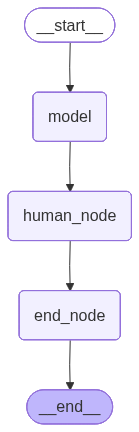

In [44]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [45]:
thread_config = {"configurable": {
    "thread_id": uuid.uuid4()
}}

In [47]:
tweet_topic = input("Enter your Tweet topic: ")
initial_state = {
    "tweet_topic": tweet_topic, 
    "generated_post": [], 
    "human_feedback": []
}

In [48]:
for chunk in app.stream(initial_state, config=thread_config):
    for node_id, value in chunk.items():
        #  If we reach an interrupt, continuously ask for human feedback

        if(node_id == "__interrupt__"):
            while True: 
                user_feedback = input("Provide feedback (or type 'done' when finished): ")

                # Resume the graph execution with the user's feedback
                app.invoke(Command(resume=user_feedback), config=thread_config)

                # Exit loop if user says done
                if user_feedback.lower() == "done":
                    break

[model] Generating content
[model_node] Generated post:
"Embrace the joy of flying with #IndigoIndia. Providing excellent service, punctual arrivals & the comfort every traveler needs! Experience India like never before. Let's paint the skies blue together. 🌏✈️💙 #Travel #IndigoAirlines #TravelIndia"


 [human_node] awaiting human feedback...

 [human_node] awaiting human feedback...
[human_node] Received human feedback: done

[end_node] Process finished
Final Generated Post: content='"Embrace the joy of flying with #IndigoIndia. Providing excellent service, punctual arrivals & the comfort every traveler needs! Experience India like never before. Let\'s paint the skies blue together. 🌏✈️💙 #Travel #IndigoAirlines #TravelIndia"' additional_kwargs={} response_metadata={} id='c0a8d59e-e956-44cc-9a30-c546b3f14276'
Final Human Feedback [HumanMessage(content='Finalised', additional_kwargs={}, response_metadata={}, id='8e627c70-0f6a-4aff-a72e-69c4846fb0d0')]
